# Personal-user retention — findings for the meeting

OBDeleven personal users, **14-day** person-interval data. An event is churn: **160 days with no activity**. Time is days since first observed activity.

Grouped charts use people still observed at **day 56**, with labels from that first 56-day window (not a frozen first-week snapshot). The overall curve still uses everyone. Onboarding delay is known at first open, so that KM uses the full sample and starts at **day 28**.

The Cox is a counting-process model on the interval rows: coefficients update every 14 days. There is no landmark Cox.


In [19]:
import os
from pathlib import Path

PROJECT_ROOT = next(
    candidate
    for parent in (Path.cwd(), *Path.cwd().parents)
    for candidate in (parent, parent / "Coding")
    if (candidate / "src").is_dir() and (candidate / "notebooks").is_dir()
)
os.chdir(PROJECT_ROOT)
PROJECT_ROOT

PosixPath('/Users/tomas.p/Desktop/Survival_Analysis_Thesis/Coding')

In [20]:
import warnings

import matplotlib.pyplot as plt
from IPython.display import display
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.gridspec import GridSpec
from scipy import stats
from statsmodels.duration.hazard_regression import PHReg
from statsmodels.duration.survfunc import SurvfuncRight

from src.constants import paths_to_files_and_folders as const
from src.constants import thesis_plotting_style as style
from src.constants import variables_groupings as vg

sns.set_theme(**style.SEABORN_THEME)
plt.rcParams.update(
    {
        "figure.dpi": 120,
        "savefig.dpi": 300,
        "font.family": style.FONT,
        "axes.titleweight": "bold",
        "figure.titlesize": 12,
        "figure.titleweight": "bold",
    }
)

FEATURES_PATH = (
    const.PATH_TO_FINAL_DATA / "features_personal_14_day_intervals_new_features.csv"
)
FIGURE_DIR = PROJECT_ROOT.parent / "Output" / "06_retention_findings"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

T_MAX = 730  # two-year window for the charts; longer follow-up still enters the estimator
RISK_TIMES = (0, 90, 180, 365, 730)
GROUP_COLORS = [
    style.PALETTE["Professional"],
    style.PALETTE["Personal"],
    style.COLORS["accent"],
    style.COLORS["highlight"],
    style.PALETTE["Neutral"],
]

## Data

One row per user for the Kaplan–Meier charts: time is the end of their last 14-day interval, and the event flag is whether churn ever fired.

`n_sessions_0_28_days` is distinct calendar days with at least one action, summed over the current 14-day interval plus the previous one. A full **56-day** count is that value on the row that closes at day 28 **plus** the same column on the row that closes at day 56 (days 28–56; no overlap). Grouped KM charts drop the 145 people who never reach day 56.


In [21]:
intervals = (
    pd.read_csv(FEATURES_PATH)
    .sort_values(["user_id", "interval_start"])
    .reset_index(drop=True)
)
intervals["event"] = (
    intervals["churn_triggered_adjusted"]
    .astype(str)
    .str.lower()
    .isin(["true", "1"])
    .astype(int)
)

person = intervals.groupby("user_id", as_index=False).agg(
    time=("interval_end", "max"),
    event=("event", "max"),
    n_intervals=("interval_start", "count"),
)
first = intervals.groupby("user_id", as_index=False).first()
drop_from_first = ["interval_start", "interval_end", "churn_triggered_adjusted", "event"]
users = person.merge(first.drop(columns=drop_from_first, errors="ignore"), on="user_id")

# Rolling 28-day session count = current 14-day interval + previous 14-day
# interval (0 if missing). The first row is therefore only ~14 days of history.
# Use the row that closes at day 28 / day 56 instead.
at_28 = intervals.loc[
    intervals["interval_end"] == 28,
    ["user_id", "n_sessions_0_28_days", "n_new_vehicles_0_28_days"],
].rename(
    columns={
        "n_sessions_0_28_days": "active_days_28",
        "n_new_vehicles_0_28_days": "vehicles_28",
    }
)
at_56 = intervals.loc[
    intervals["interval_end"] == 56, ["user_id", "n_sessions_0_28_days"]
].rename(columns={"n_sessions_0_28_days": "active_days_28_to_56"})
users = users.merge(at_28, on="user_id", how="left").merge(at_56, on="user_id", how="left")
users["reached_56"] = users["active_days_28_to_56"].notna()
users["active_days_56"] = np.where(
    users["reached_56"],
    users["active_days_28"] + users["active_days_28_to_56"],
    np.nan,
)

ACTIVITY_BINS = [-0.1, 1, 3, 100]
ACTIVITY_LABELS = ["1 active day", "2–3 active days", "4+ active days"]

row56 = intervals.loc[intervals["interval_end"] == 56].copy()
users_56 = person.merge(
    row56.drop(columns=["interval_start", "interval_end", "churn_triggered_adjusted", "event"], errors="ignore"),
    on="user_id",
    validate="one_to_one",
)
users_56 = users_56.merge(users[["user_id", "active_days_28", "vehicles_28"]], on="user_id")
users_56["active_days_56"] = users_56["active_days_28"] + users_56["n_sessions_0_28_days"]
users_56["vehicles_56"] = users_56["vehicles_28"] + users_56["n_new_vehicles_0_28_days"]
users_56["activity_56"] = pd.cut(
    users_56["active_days_56"], bins=ACTIVITY_BINS, labels=ACTIVITY_LABELS
)
users_56["feature_mix"] = np.select(
    [users_56["prop_coding_0_56"] > 0, users_56["prop_oca_0_56"] > 0],
    ["Used coding", "Used One-Click Apps"],
    default="Diagnostics only",
)
users_56["brand"] = np.select(
    [
        users_56["overall_prop_vehicle_make_volkswagen"] >= 0.5,
        users_56["overall_prop_vehicle_make_audi"] >= 0.5,
        users_56["overall_prop_vehicle_make_skoda"] >= 0.5,
    ],
    ["Volkswagen", "Audi", "Škoda"],
    default="Other / mixed",
)
users_56["app"] = np.select(
    [users_56["prop_main_0_56"] >= 0.75, users_56["prop_main_0_56"] <= 0.25],
    ["Main app", "VAG app"],
    default="Both apps",
)
users["onboarding"] = np.select(
    [users["onboarding_delay_days"] <= 2, users["onboarding_delay_days"] < 28],
    ["Opened in ≤2 days", "Opened in 3–27 days"],
    default="Opened after 28+ days",
)
users_56 = users_56.merge(users[["user_id", "onboarding"]], on="user_id")
users_56["cleared_codes"] = np.where(
    users_56["prop_clear_0_56"] > 0, "Cleared fault codes", "Did not clear codes"
)
users_56["live_data"] = np.where(
    users_56["prop_live_data_0_56"] > 0, "Used live data", "No live data"
)
users_56["garage"] = np.select(
    [users_56["vehicles_56"] >= 3, users_56["vehicles_56"] == 2],
    ["3+ vehicles in first 56d", "2 vehicles in first 56d"],
    default="1 vehicle in first 56d",
)
users_56["session_depth"] = pd.qcut(
    users_56["actions_per_session_0_28_days"].rank(method="first"),
    3,
    labels=["Shallow sessions", "Typical depth", "Deep sessions"],
)

print(
    f"{len(intervals):,} intervals | {len(users):,} personal users | "
    f"{int(users['event'].sum()):,} churned "
    f"({users['event'].mean():.0%}) | median follow-up {users['time'].median():.0f} days | "
    f"{len(users_56):,} users observed through day 56 (most grouped charts); onboarding KM uses everyone from day 28"
)


143,927 intervals | 6,458 personal users | 3,228 churned (50%) | median follow-up 280 days | 6,012 users observed through day 56 (most grouped charts); onboarding KM uses everyone from day 28


## Plot helpers

Kaplan–Meier with Greenwood bands, a log-rank test, median time to churn, and an at-risk table. Axis language is “still active”, not “survival”.

In [22]:
def survival_at(sf: SurvfuncRight, t: float) -> float:
    past = sf.surv_times <= t
    return float(sf.surv_prob[past][-1]) if past.any() else 1.0


def median_time(sf: SurvfuncRight) -> float:
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        try:
            value = float(sf.quantile(0.5))
        except (IndexError, ValueError, TypeError):
            return np.nan
    return value if np.isfinite(value) else np.nan


def format_days(value: float) -> str:
    if not np.isfinite(value):
        return "not reached"
    return f"{value:.0f}d"


def format_p(p: float) -> str:
    if not np.isfinite(p):
        return "n/a"
    if p < 0.001:
        return "p < 0.001"
    return f"p = {p:.3f}"


def k_sample_logrank(time: np.ndarray, event: np.ndarray, group: np.ndarray):
    """Mantel–Haenszel k-sample log-rank (two-sided)."""
    time = np.asarray(time, dtype=float)
    event = np.asarray(event, dtype=int)
    group = np.asarray(group)
    levels = pd.unique(group)
    n_groups = len(levels)
    if n_groups < 2:
        return np.nan, np.nan

    observed = np.zeros(n_groups)
    expected = np.zeros(n_groups)
    variance = np.zeros((n_groups, n_groups))

    for t in np.unique(time[event == 1]):
        at_risk = time >= t
        died = (time == t) & (event == 1)
        n = np.array([(at_risk & (group == g)).sum() for g in levels], dtype=float)
        d = np.array([(died & (group == g)).sum() for g in levels], dtype=float)
        n_tot, d_tot = n.sum(), d.sum()
        if n_tot < 2 or d_tot == 0:
            continue
        e = d_tot * n / n_tot
        observed += d
        expected += e
        frac = n / n_tot
        variance += (
            d_tot * (n_tot - d_tot) / (n_tot - 1) * (np.diag(frac) - np.outer(frac, frac))
        )

    delta = (observed - expected)[:-1]
    v_red = variance[:-1, :-1]
    try:
        stat = float(delta @ np.linalg.pinv(v_red) @ delta)
    except np.linalg.LinAlgError:
        return np.nan, np.nan
    p_value = float(stats.chi2.sf(stat, n_groups - 1))
    return stat, p_value


def fit_group_curves(frame: pd.DataFrame, group_col: str | None):
    if group_col is None:
        labelled = frame.assign(_group="All personal users")
        group_col = "_group"
        order = ["All personal users"]
    else:
        labelled = frame.dropna(subset=[group_col]).copy()
        labelled[group_col] = labelled[group_col].astype(str)
        order = [str(x) for x in labelled[group_col].unique()]
        if hasattr(frame[group_col], "cat"):
            order = [str(x) for x in frame[group_col].cat.categories if str(x) in set(order)]

    fits = {}
    for name in order:
        part = labelled.loc[labelled[group_col] == name]
        fits[name] = {
            "sf": SurvfuncRight(part["time"].to_numpy(), part["event"].to_numpy()),
            "n": int(len(part)),
            "events": int(part["event"].sum()),
            "time": part["time"].to_numpy(),
            "event": part["event"].to_numpy(),
        }
    _, p_value = k_sample_logrank(
        labelled["time"].to_numpy(),
        labelled["event"].to_numpy(),
        labelled[group_col].to_numpy(),
    )
    return fits, p_value


def _km_step(sf: SurvfuncRight, t_max: float, t_min: float = 0.0, last_time: float | None = None):
    times = np.concatenate(([float(t_min)], sf.surv_times.astype(float)))
    surv = np.concatenate(([1.0], sf.surv_prob.astype(float)))
    se = np.concatenate(([0.0], np.nan_to_num(sf.surv_prob_se.astype(float), nan=0.0)))
    t_end = t_max if last_time is None else min(t_max, float(last_time))
    keep = (times >= t_min) & (times <= t_end)
    times, surv, se = times[keep], surv[keep], se[keep]
    if len(times) == 0 or times[0] > t_min:
        times = np.insert(times, 0, t_min)
        surv = np.insert(surv, 0, 1.0)
        se = np.insert(se, 0, 0.0)
    if times[-1] < t_end:
        times = np.append(times, t_end)
        surv = np.append(surv, surv[-1])
        se = np.append(se, se[-1])
    lo = np.clip(surv - 1.96 * se, 0.0, 1.0)
    hi = np.clip(surv + 1.96 * se, 0.0, 1.0)
    return times, surv, lo, hi


def _style_km_axis(ax, t_max: float, t_min: float = 0.0):
    ax.set_xlim(t_min, t_max)
    ax.set_ylim(0, 1.02)
    ax.set_yticks([0, 0.25, 0.5, 0.75, 1.0])
    ax.set_yticklabels(["0%", "25%", "50%", "75%", "100%"])
    ax.set_xlabel("Days since first activity", labelpad=8)
    ax.set_ylabel("Still active", labelpad=8)
    ax.grid(axis="x", visible=False)
    ax.grid(axis="y", linestyle="--", linewidth=0.6, alpha=0.45)
    ax.set_axisbelow(True)
    ax.tick_params(length=0)
    sns.despine(ax=ax, left=True)
    ax.axhline(0.5, color=style.COLORS["axis"], lw=0.8, ls=":")


def plot_km(
    frame: pd.DataFrame,
    group_col: str | None,
    title: str,
    filename: str,
    order: list[str] | None = None,
    t_max: int = T_MAX,
    show_risk: bool = True,
    ax: plt.Axes | None = None,
    t_min: float | None = None,
):
    fits, p_value = fit_group_curves(frame, group_col)
    if order:
        fits = {name: fits[name] for name in order if name in fits}

    if t_min is None:
        t_min = 56 if float(frame["time"].min()) >= 56 else 0
    if t_min >= 56:
        # 90 sits too close to the day-56 origin: the two risk numbers overlap.
        risk_times = (56, 180, 365, 730)
    elif t_min >= 28:
        risk_times = (28, 180, 365, 730)
    else:
        risk_times = RISK_TIMES

    n_groups = len(fits)
    colors = [style.PALETTE["Personal"]] if n_groups == 1 else GROUP_COLORS
    own_fig = ax is None
    ax_risk = None

    if own_fig:
        risk_h = 0.42 + 0.26 * max(n_groups, 1)
        fig = plt.figure(figsize=(8.8, 4.6 + (1.15 if show_risk else 0.15)))
        header = 0.40
        if show_risk:
            spec = GridSpec(
                3,
                1,
                height_ratios=[header, 4.2, risk_h],
                hspace=0.10,
                left=0.24,
                right=0.98,
                top=0.98,
                bottom=0.10,
                figure=fig,
            )
            ax_head = fig.add_subplot(spec[0])
            ax = fig.add_subplot(spec[1])
            ax_risk = fig.add_subplot(spec[2])
        else:
            spec = GridSpec(
                2,
                1,
                height_ratios=[header, 4.0],
                hspace=0.08,
                left=0.12,
                right=0.98,
                top=0.97,
                bottom=0.14,
                figure=fig,
            )
            ax_head = fig.add_subplot(spec[0])
            ax = fig.add_subplot(spec[1])
        ax_head.axis("off")
        if group_col is None:
            subtitle = f"Median time to churn: {format_days(median_time(next(iter(fits.values()))['sf']))}"
        else:
            subtitle = f"Log-rank {format_p(p_value)}"
        ax_head.text(
            0,
            0.92,
            title,
            ha="left",
            va="top",
            fontsize=12,
            fontweight="bold",
            color=style.COLORS["text"],
            transform=ax_head.transAxes,
        )
        ax_head.text(
            0,
            0.28,
            subtitle,
            ha="left",
            va="top",
            fontsize=9,
            color=style.COLORS["secondary_text"],
            transform=ax_head.transAxes,
        )
    else:
        fig = ax.figure
        show_risk = False
        ax.set_title(title, loc="left", color=style.COLORS["text"], pad=6, fontweight="bold")

    for i, (name, payload) in enumerate(fits.items()):
        color = colors[i % len(colors)]
        times, surv, lo, hi = _km_step(
            payload["sf"], t_max, t_min=t_min, last_time=float(np.max(payload["time"]))
        )
        median = median_time(payload["sf"])
        if own_fig:
            label = f"{name}  (n={payload['n']:,}; median {format_days(median)})"
        else:
            label = f"{name}  (n={payload['n']:,})"
        ax.fill_between(times, lo, hi, step="post", color=color, alpha=0.14, linewidth=0)
        ax.plot(
            times,
            surv,
            drawstyle="steps-post",
            color=color,
            lw=2.15,
            label=label,
        )

    _style_km_axis(ax, t_max, t_min=t_min)
    ax.set_xticks(list(risk_times))
    if show_risk:
        ax.set_xlabel("")
        ax.tick_params(axis="x", bottom=False, labelbottom=False)
    if own_fig:
        ax.legend(
            loc="upper right",
            fontsize=8,
            handlelength=1.5,
            borderaxespad=0.4,
            frameon=True,
            facecolor=style.COLORS["background"],
            edgecolor="none",
            framealpha=0.92,
        )
    else:
        ax.legend(loc="upper right", fontsize=7.2, handlelength=1.3, borderaxespad=0.25)
        if group_col:
            ax.text(
                1.0,
                1.03,
                f"Log-rank {format_p(p_value)}",
                transform=ax.transAxes,
                ha="right",
                va="bottom",
                color=style.COLORS["secondary_text"],
                fontsize=8,
            )

    if show_risk and ax_risk is not None:
        ax_risk.set_xlim(t_min, t_max)
        ax_risk.set_xticks(list(risk_times))
        ax_risk.set_ylim(-0.55, n_groups - 0.45)
        ax_risk.set_yticks(range(n_groups))
        ax_risk.set_yticklabels([])
        ax_risk.tick_params(axis="y", left=False, length=0)
        ax_risk.set_title(
            "Users still in follow-up",
            loc="left",
            fontsize=8,
            color=style.COLORS["secondary_text"],
            pad=6,
            fontweight="regular",
        )
        ax_risk.set_xlabel("Days since first activity", labelpad=8)
        ax_risk.set_ylabel("")
        ax_risk.grid(False)
        sns.despine(ax=ax_risk, left=True)
        for i, (name, payload) in enumerate(fits.items()):
            ax_risk.text(
                -0.02,
                i,
                name,
                transform=ax_risk.get_yaxis_transform(),
                ha="right",
                va="center",
                fontsize=8,
                color=colors[i % len(colors)],
                fontweight="bold",
                clip_on=False,
            )
            for t in risk_times:
                ax_risk.text(
                    t + (8 if t == t_min else 0),
                    i,
                    f"{int((payload['time'] >= t).sum()):,}",
                    ha="left" if t == t_min else "center",
                    va="center",
                    fontsize=8,
                    color=style.COLORS["text"],
                )

    if own_fig:
        fig.savefig(
            FIGURE_DIR / filename,
            bbox_inches="tight",
            pad_inches=0.15,
            facecolor=style.COLORS["background"],
        )
        plt.show()
    return fits, p_value


def retention_table(frame: pd.DataFrame, group_col: str, order: list[str] | None = None) -> pd.DataFrame:
    fits, p_value = fit_group_curves(frame, group_col)
    if order:
        names = [name for name in order if name in fits]
    else:
        names = list(fits)
    rows = []
    for name in names:
        payload = fits[name]
        sf = payload["sf"]
        rows.append(
            {
                "Group": name,
                "Users": payload["n"],
                "Churned": payload["events"],
                "Still active at 90d": survival_at(sf, 90),
                "Still active at 180d": survival_at(sf, 180),
                "Still active at 365d": survival_at(sf, 365),
                "Median days to churn": median_time(sf),
            }
        )
    table = pd.DataFrame(rows)
    table.attrs["logrank_p"] = p_value
    return table


def show_table(table: pd.DataFrame):
    p_value = table.attrs.get("logrank_p", np.nan)
    styled = (
        table.style.format(
            {
                "Users": "{:,.0f}",
                "Churned": "{:,.0f}",
                "Still active at 90d": "{:.0%}",
                "Still active at 180d": "{:.0%}",
                "Still active at 365d": "{:.0%}",
                "Median days to churn": lambda v: format_days(v),
            }
        )
        .hide(axis="index")
        .set_caption(f"Log-rank {format_p(p_value)}")
        .set_properties(**{"text-align": "left", "color": style.COLORS["text"]})
    )
    return styled


def occurrence_table(series: pd.Series) -> pd.DataFrame:
    counts = series.dropna().astype(int).value_counts().sort_index()
    return pd.DataFrame(
        {
            "Distinct active days": counts.index,
            "Users": counts.values,
            "Share": counts.values / counts.sum(),
        }
    )


def plot_occurrences(
    series: pd.Series,
    title: str,
    filename: str,
    xlabel: str,
    cap_at: int = 16,
):
    counts = series.dropna().astype(int)
    clipped = counts.clip(upper=cap_at)
    vc = clipped.value_counts().sort_index()
    labels = [str(i) if i < cap_at else f"{cap_at}+" for i in vc.index]
    fig, ax = plt.subplots(figsize=(8.8, 3.8))
    bars = ax.bar(
        range(len(vc)),
        vc.values,
        color=style.PALETTE["Personal"],
        edgecolor=style.COLORS["text"],
        linewidth=0.6,
    )
    ymax = max(vc.values) * 1.14
    ax.set_ylim(0, ymax)
    for bar, n in zip(bars, vc.values):
        ax.annotate(
            f"{n:,}",
            xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
            xytext=(0, 3),
            textcoords="offset points",
            ha="center",
            va="bottom",
            fontsize=7.5,
            color=style.COLORS["text"],
        )
    ax.set_xticks(range(len(vc)), labels)
    ax.set_xlabel(xlabel, labelpad=8)
    ax.set_ylabel("Users", labelpad=8)
    ax.set_title(title, loc="left", color=style.COLORS["text"], pad=8)
    ax.grid(axis="x", visible=False)
    ax.grid(axis="y", linestyle="--", linewidth=0.6, alpha=0.45)
    ax.set_axisbelow(True)
    ax.tick_params(length=0)
    sns.despine(ax=ax, left=True)
    fig.savefig(FIGURE_DIR / filename, bbox_inches="tight", facecolor=style.COLORS["background"])
    plt.show()
    return vc


## 1. How long do personal users stay?

This is the baseline the other charts should beat. The shaded band is a 95% Greenwood interval. The x-axis is cut at two years so the early drop is readable; users followed longer still count in the curve.

Personal users,Churned,Still active at 90d,Still active at 180d,Still active at 365d,Median days to churn
"6,458","3,228",84%,69%,52%,420d


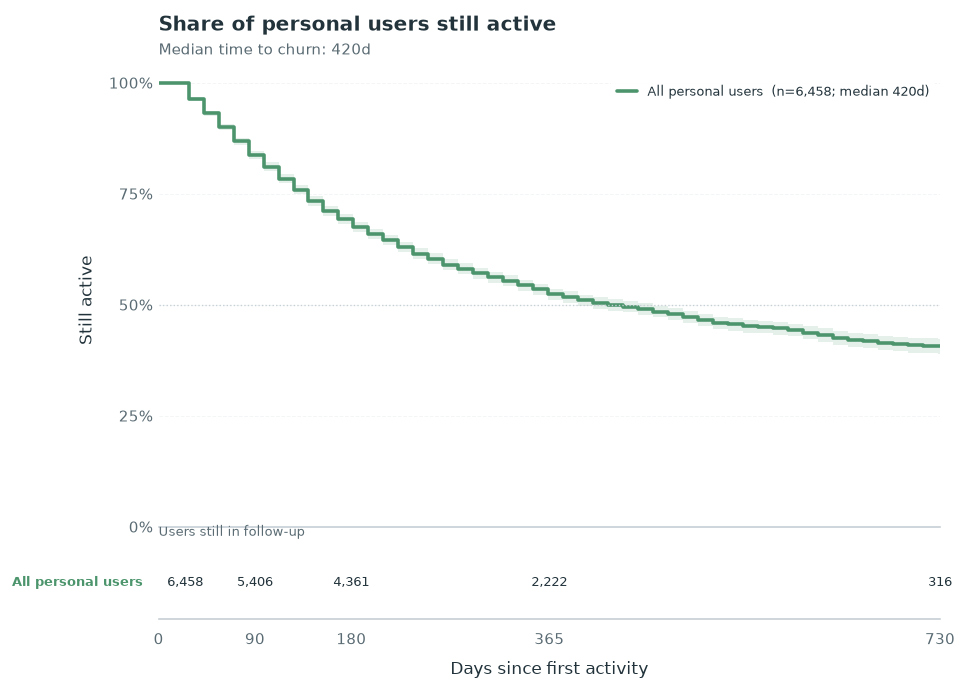

({'All personal users': {'sf': <statsmodels.duration.survfunc.SurvfuncRight at 0x11e68dc10>,
   'n': 6458,
   'events': 3228,
   'time': array([784,  70, 378, ..., 266, 448, 238], shape=(6458,)),
   'event': array([0, 1, 0, ..., 0, 0, 1], shape=(6458,))}},
 nan)

In [23]:
overall_sf = SurvfuncRight(users["time"].to_numpy(), users["event"].to_numpy())
kpi = pd.DataFrame(
    [
        {
            "Personal users": len(users),
            "Churned": int(users["event"].sum()),
            "Still active at 90d": survival_at(overall_sf, 90),
            "Still active at 180d": survival_at(overall_sf, 180),
            "Still active at 365d": survival_at(overall_sf, 365),
            "Median days to churn": median_time(overall_sf),
        }
    ]
)
display(
    kpi.style.format(
        {
            "Personal users": "{:,.0f}",
            "Churned": "{:,.0f}",
            "Still active at 90d": "{:.0%}",
            "Still active at 180d": "{:.0%}",
            "Still active at 365d": "{:.0%}",
            "Median days to churn": lambda v: format_days(v),
        }
    ).hide(axis="index")
)

plot_km(
    users,
    group_col=None,
    title="Share of personal users still active",
    filename="01_overall_retention.png",
)

## 2. Distinct active days in the first 56 days

`n_sessions_0_28_days` counts distinct calendar days with at least one action over two adjacent 14-day intervals. The 56-day total is that count at day 28 plus the count at day 56.

Only the 1,800 users who reach day 56 are in this chart. KM groups: 1 day / 2–3 days / 4+ days.


6,012 / 6,458 users reach day 56; 446 are left out of grouped charts.


Distinct active days,Users,Share
1,654,10.9%
2,782,13.0%
3,829,13.8%
4,688,11.4%
5,576,9.6%
6,491,8.2%
7,398,6.6%
8,284,4.7%
9,230,3.8%
10,183,3.0%


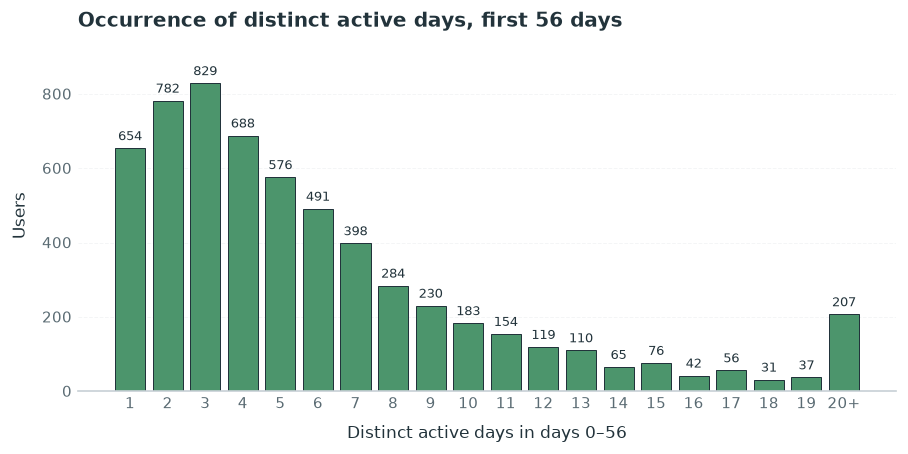

Group,Users,Churned,Still active at 90d,Still active at 180d,Still active at 365d,Median days to churn
1 active day,654,454,85%,61%,34%,224d
2–3 active days,"1,611",933,88%,67%,44%,308d
4+ active days,"3,747","1,399",92%,80%,65%,not reached


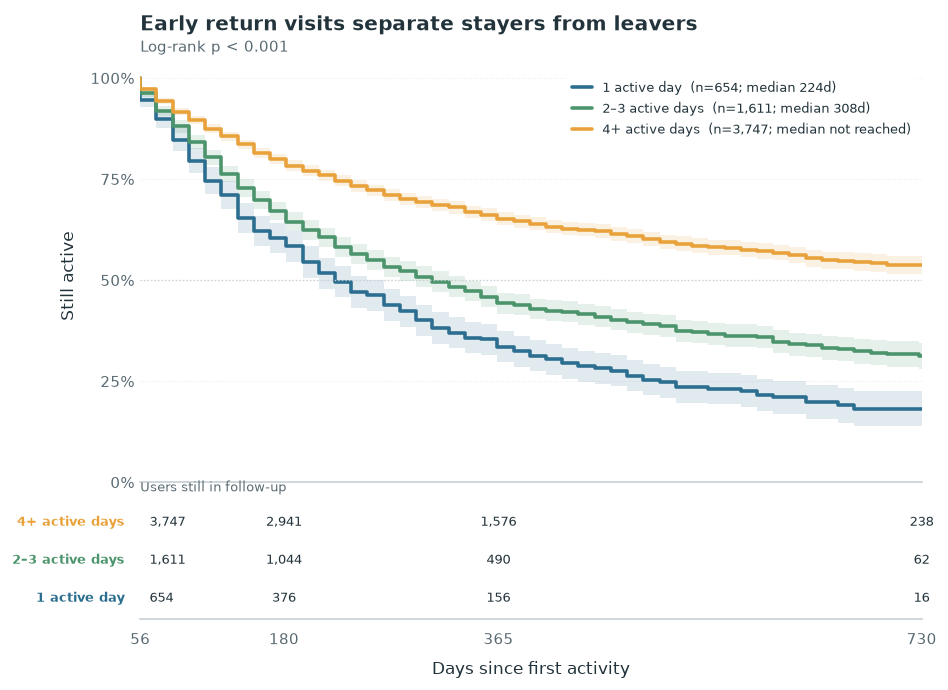

({'1 active day': {'sf': <statsmodels.duration.survfunc.SurvfuncRight at 0x11e1f1340>,
   'n': 654,
   'events': 454,
   'time': array([210, 546, 490, 224, 294, 294, 112, 196,  84,  98, 434, 210, 532,
          224, 308, 518, 630, 322, 392, 224, 294, 518, 364,  56, 210,  98,
           84, 378, 266, 112, 140, 644, 266, 210,  98, 112, 294,  56, 742,
          224, 140,  70,  98, 308, 140, 308,  98,  98, 140, 322,  84, 266,
          490,  84, 280,  84, 518, 266, 112,  84, 182, 140,  56, 308, 476,
          140, 210, 476, 140, 364,  70, 210, 448, 238,  70, 266,  56, 154,
           84,  84, 196,  56, 574, 350, 462, 322, 294, 238, 126, 434, 196,
          308, 168, 322,  84, 140, 504, 574,  84, 280, 210,  84,  70, 420,
          168,  70, 322, 308, 448, 336, 448, 112,  56, 140, 140,  70,  98,
          196,  70, 518, 224, 714, 154, 182, 168, 644,  98,  70, 322,  84,
          126,  84, 322, 350, 238, 658, 154, 490, 126, 490, 532, 448, 154,
          686, 588, 112, 252, 140, 126,  56, 434,

In [24]:
activity_order = ["1 active day", "2–3 active days", "4+ active days"]

print(
    f"{len(users_56):,} / {len(users):,} users reach day 56; "
    f"{len(users) - len(users_56):,} are left out of grouped charts."
)
occ_56 = occurrence_table(users_56["active_days_56"])
display(
    occ_56.style.format({"Users": "{:,.0f}", "Share": "{:.1%}"})
    .hide(axis="index")
    .set_caption("How many users had exactly k distinct active days in days 0–56")
)
plot_occurrences(
    users_56["active_days_56"],
    title="Occurrence of distinct active days, first 56 days",
    filename="02_active_days_56_counts.png",
    xlabel="Distinct active days in days 0–56",
    cap_at=20,
)

display(show_table(retention_table(users_56, "activity_56", activity_order)))
plot_km(
    users_56,
    "activity_56",
    title="Early return visits separate stayers from leavers",
    filename="02_early_active_days.png",
    order=activity_order,
)


Grouped charts below use the same day-56 sample. “Both apps” / live data / coding are what they did in that 56-day window, not a lifetime label.


In [25]:
print("Grouped KM sample:", f"{len(users_56):,} users still observed at day 56")


Grouped KM sample: 6,012 users still observed at day 56


## 3. What they do in those first 56 days

Coding (paid / power-user), One-Click Apps, or diagnostics-only (mostly scan). Curves are unadjusted: coding users also tend to be more active, which the Cox coefficients later separate.


Group,Users,Churned,Still active at 90d,Still active at 180d,Still active at 365d,Median days to churn
Used coding,"1,478",542,94%,82%,67%,not reached
Used One-Click Apps,"2,196",968,91%,76%,58%,588d
Diagnostics only,"2,338","1,276",87%,69%,48%,350d


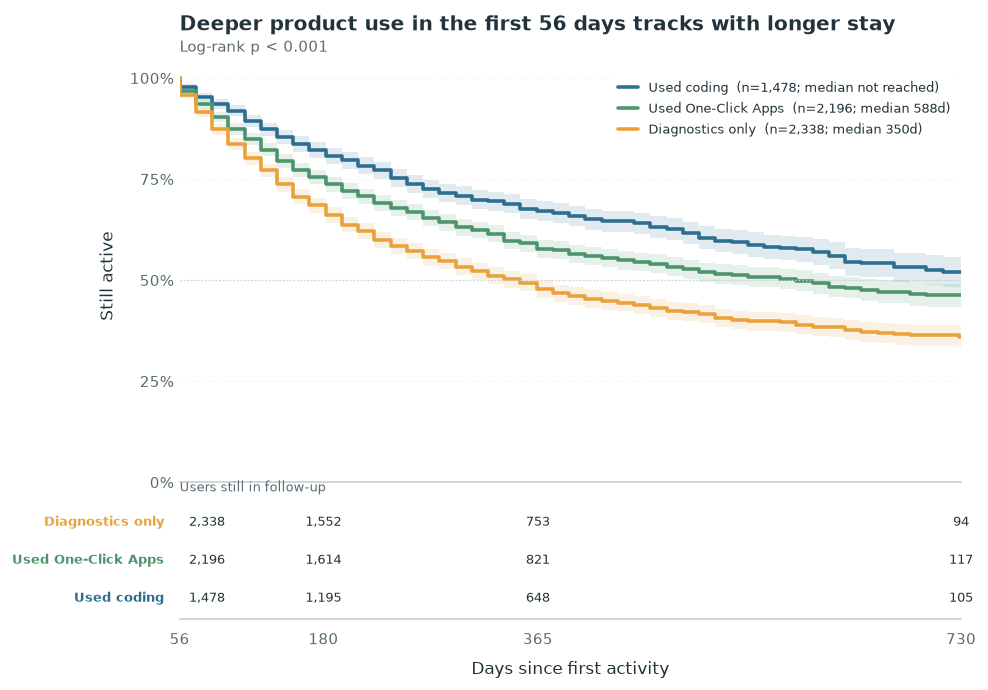

({'Used coding': {'sf': <statsmodels.duration.survfunc.SurvfuncRight at 0x11e78b4a0>,
   'n': 1478,
   'events': 542,
   'time': array([784, 714, 378, ..., 938, 882, 756], shape=(1478,)),
   'event': array([0, 0, 0, ..., 0, 0, 0], shape=(1478,))},
  'Used One-Click Apps': {'sf': <statsmodels.duration.survfunc.SurvfuncRight at 0x11e3471d0>,
   'n': 2196,
   'events': 968,
   'time': array([140, 672, 602, ..., 952, 490, 238], shape=(2196,)),
   'event': array([1, 0, 0, ..., 0, 0, 1], shape=(2196,))},
  'Diagnostics only': {'sf': <statsmodels.duration.survfunc.SurvfuncRight at 0x11db02510>,
   'n': 2338,
   'events': 1276,
   'time': array([ 70, 378, 630, ..., 504, 266, 448], shape=(2338,)),
   'event': array([1, 0, 1, ..., 0, 0, 0], shape=(2338,))}},
 5.077385344606439e-31)

In [26]:
mix_order = ["Used coding", "Used One-Click Apps", "Diagnostics only"]
display(show_table(retention_table(users_56, "feature_mix", mix_order)))
plot_km(
    users_56,
    "feature_mix",
    title="Deeper product use in the first 56 days tracks with longer stay",
    filename="03_feature_mix.png",
    order=mix_order,
)


## 4. Going beyond a scan

Clearing fault codes and opening live data in the first 56 days. Unadjusted KM; the Cox says whether the mix still matters once visit volume is in the model.


Group,Users,Churned,Still active at 90d,Still active at 180d,Still active at 365d,Median days to churn
Cleared fault codes,"3,462","1,403",91%,78%,62%,686d
Did not clear codes,"2,550","1,383",89%,70%,49%,350d


Group,Users,Churned,Still active at 90d,Still active at 180d,Still active at 365d,Median days to churn
Used live data,"2,033",711,90%,75%,63%,not reached
No live data,"3,979","2,075",90%,74%,53%,434d


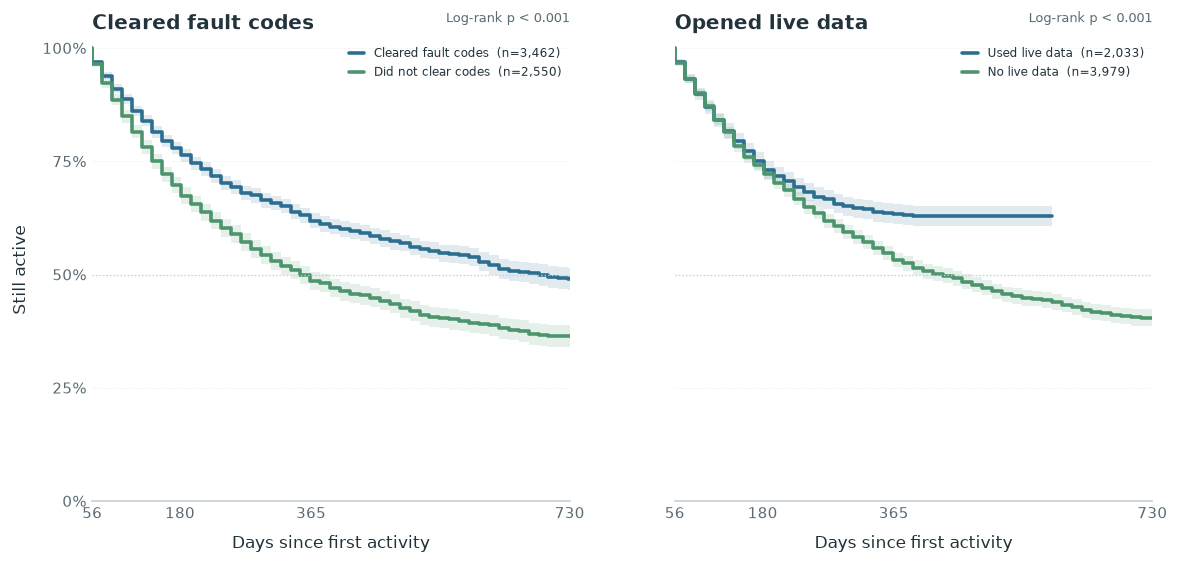

In [27]:
clear_order = ["Cleared fault codes", "Did not clear codes"]
live_order = ["Used live data", "No live data"]
display(show_table(retention_table(users_56, "cleared_codes", clear_order)))
display(show_table(retention_table(users_56, "live_data", live_order)))

fig, axes = plt.subplots(1, 2, figsize=(11.4, 5.0), sharey=True)
plot_km(
    users_56,
    "cleared_codes",
    title="Cleared fault codes",
    filename="04a_cleared_codes.png",
    order=clear_order,
    ax=axes[0],
)
plot_km(
    users_56,
    "live_data",
    title="Opened live data",
    filename="04b_live_data.png",
    order=live_order,
    ax=axes[1],
)
axes[1].set_ylabel("")
fig.subplots_adjust(wspace=0.22, top=0.88)
fig.savefig(FIGURE_DIR / "04_beyond_scan.png", bbox_inches="tight", pad_inches=0.15, facecolor=style.COLORS["background"])
plt.show()


## 5. How many vehicles show up in the first 56 days

Not a lifetime fleet census: distinct vehicles first seen in days 0–56 (`n_new_vehicles` at day 28 plus the same column at day 56).


Group,Users,Churned,Still active at 90d,Still active at 180d,Still active at 365d,Median days to churn
3+ vehicles in first 56d,"1,339",452,93%,83%,69%,not reached
2 vehicles in first 56d,"1,595",696,90%,75%,58%,630d
1 vehicle in first 56d,"3,078","1,638",89%,70%,50%,364d


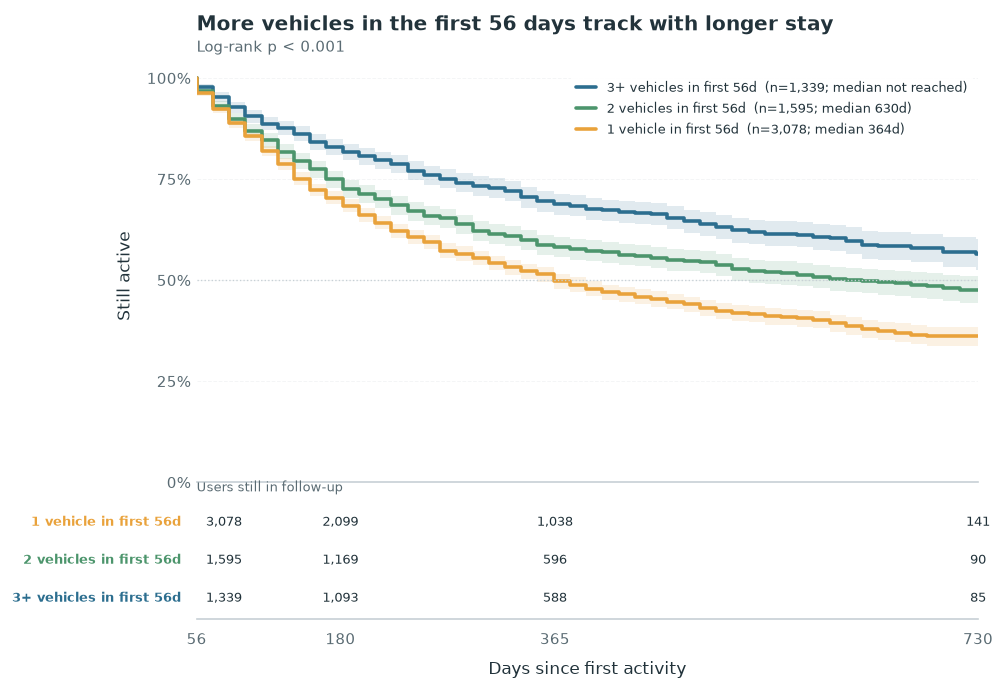

({'3+ vehicles in first 56d': {'sf': <statsmodels.duration.survfunc.SurvfuncRight at 0x11e3e37d0>,
   'n': 1339,
   'events': 452,
   'time': array([378, 252, 350, ..., 672, 504, 238], shape=(1339,)),
   'event': array([0, 0, 0, ..., 0, 0, 1], shape=(1339,))},
  '2 vehicles in first 56d': {'sf': <statsmodels.duration.survfunc.SurvfuncRight at 0x11e515400>,
   'n': 1595,
   'events': 696,
   'time': array([784, 140, 406, ..., 938, 490, 756], shape=(1595,)),
   'event': array([0, 1, 0, ..., 0, 0, 0], shape=(1595,))},
  '1 vehicle in first 56d': {'sf': <statsmodels.duration.survfunc.SurvfuncRight at 0x11e7aab10>,
   'n': 3078,
   'events': 1638,
   'time': array([ 70, 378, 714, ..., 952, 266, 448], shape=(3078,)),
   'event': array([1, 0, 0, ..., 0, 0, 0], shape=(3078,))}},
 6.97277529670554e-33)

In [28]:
garage_order = ["3+ vehicles in first 56d", "2 vehicles in first 56d", "1 vehicle in first 56d"]
display(show_table(retention_table(users_56, "garage", garage_order)))
plot_km(
    users_56,
    "garage",
    title="More vehicles in the first 56 days track with longer stay",
    filename="05_second_vehicle.png",
    order=garage_order,
)


## 6. Time from registration to first activity

Late first-open is a weaker split than activity. The delay is known at first use, so this curve uses **all 1,945 users** and starts at **day 28** (everyone already has at least two intervals).


Group,Users,Churned,Still active at 90d,Still active at 180d,Still active at 365d,Median days to churn
Opened in ≤2 days,"3,643","1,809",84%,70%,54%,462d
Opened in 3–27 days,"1,833",924,84%,70%,52%,406d
Opened after 28+ days,982,495,83%,66%,48%,364d


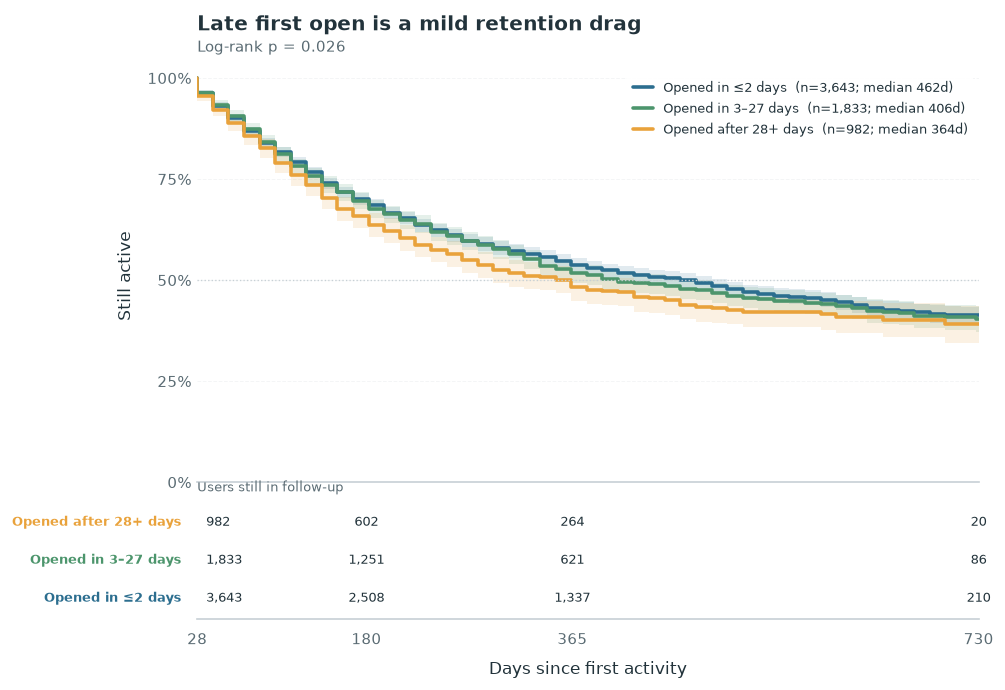

({'Opened in ≤2 days': {'sf': <statsmodels.duration.survfunc.SurvfuncRight at 0x11e4cdfd0>,
   'n': 3643,
   'events': 1809,
   'time': array([784,  70, 378, ..., 882, 756, 448], shape=(3643,)),
   'event': array([0, 1, 0, ..., 0, 0, 0], shape=(3643,))},
  'Opened in 3–27 days': {'sf': <statsmodels.duration.survfunc.SurvfuncRight at 0x11e4cd910>,
   'n': 1833,
   'events': 924,
   'time': array([630, 210, 252, ..., 490, 266, 238], shape=(1833,)),
   'event': array([1, 1, 0, ..., 0, 0, 1], shape=(1833,))},
  'Opened after 28+ days': {'sf': <statsmodels.duration.survfunc.SurvfuncRight at 0x11e5fc9e0>,
   'n': 982,
   'events': 495,
   'time': array([714, 140, 350, 266, 266, 224, 294, 602, 140, 602, 518,  84, 294,
          112, 196,  98, 210, 154, 294, 336, 196, 196, 238, 392, 168, 294,
          364, 406,  28, 364, 238, 756, 112, 378, 126, 154, 140, 112, 420,
           42, 504, 574, 210,  98, 112, 266, 336, 280,  98, 840, 140, 196,
           84, 210, 350, 378,  84, 168, 434, 154, 140,

In [29]:
onboard_order = ["Opened in ≤2 days", "Opened in 3–27 days", "Opened after 28+ days"]
display(show_table(retention_table(users, "onboarding", onboard_order)))
plot_km(
    users,
    "onboarding",
    title="Late first open is a mild retention drag",
    filename="06_onboarding_delay.png",
    order=onboard_order,
    t_min=28,
)


## 7. Main app vs VAG app

Share of main-app activity in the first 56 days: ≥75% main, ≤25% main (VAG), otherwise both. This is a snapshot, not “they always used both apps”.


Group,Users,Churned,Still active at 90d,Still active at 180d,Still active at 365d,Median days to churn
Both apps,"1,257",498,91%,76%,59%,728d
Main app,"2,142","1,033",87%,69%,50%,364d
VAG app,"2,613","1,255",92%,78%,60%,546d


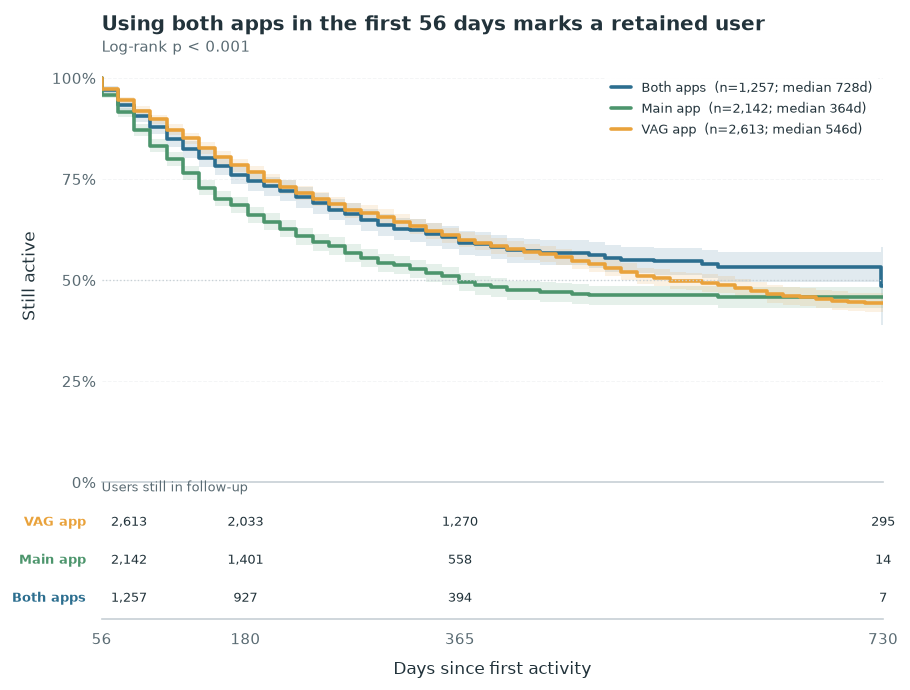

({'Both apps': {'sf': <statsmodels.duration.survfunc.SurvfuncRight at 0x11d89a4e0>,
   'n': 1257,
   'events': 498,
   'time': array([350, 364, 476, ..., 140, 364, 238], shape=(1257,)),
   'event': array([0, 0, 0, ..., 1, 0, 1], shape=(1257,))},
  'Main app': {'sf': <statsmodels.duration.survfunc.SurvfuncRight at 0x11e075370>,
   'n': 2142,
   'events': 1033,
   'time': array([378, 602, 350, ..., 504, 490, 448], shape=(2142,)),
   'event': array([0, 0, 0, ..., 0, 0, 0], shape=(2142,))},
  'VAG app': {'sf': <statsmodels.duration.survfunc.SurvfuncRight at 0x11e0748f0>,
   'n': 2613,
   'events': 1255,
   'time': array([784,  70, 714, ..., 952, 756, 266], shape=(2613,)),
   'event': array([0, 1, 0, ..., 0, 0, 0], shape=(2613,))}},
 1.814112938411315e-11)

In [30]:
app_order = ["Both apps", "Main app", "VAG app"]
display(show_table(retention_table(users_56, "app", app_order)))
plot_km(
    users_56,
    "app",
    title="Using both apps in the first 56 days marks a retained user",
    filename="07_app.png",
    order=app_order,
)


## 8. Vehicle brand — mostly a non-finding

VW, Audi and Škoda personal users leave at similar rates. Brand mix is not where retention work should go.

Group,Users,Churned,Still active at 90d,Still active at 180d,Still active at 365d,Median days to churn
Volkswagen,"2,902","1,353",90%,74%,56%,518d
Audi,"1,959",903,91%,75%,57%,518d
Škoda,462,211,91%,74%,55%,490d
Other / mixed,689,319,89%,74%,55%,518d


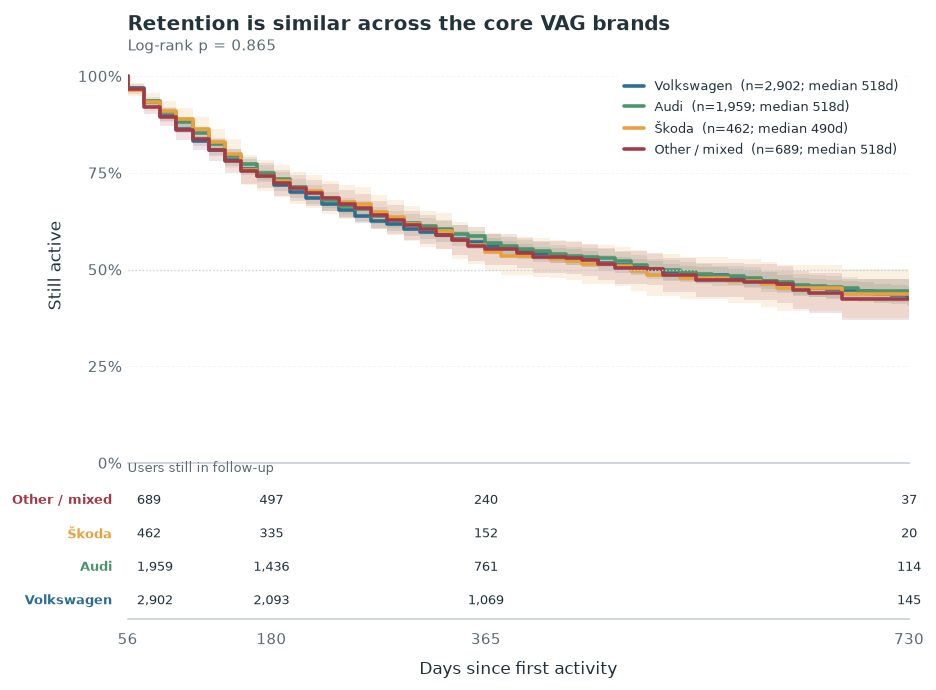

({'Volkswagen': {'sf': <statsmodels.duration.survfunc.SurvfuncRight at 0x11e6a65d0>,
   'n': 2902,
   'events': 1353,
   'time': array([ 70, 378, 378, ..., 490, 756, 266], shape=(2902,)),
   'event': array([1, 0, 0, ..., 0, 0, 0], shape=(2902,))},
  'Audi': {'sf': <statsmodels.duration.survfunc.SurvfuncRight at 0x11e6a5a60>,
   'n': 1959,
   'events': 903,
   'time': array([714, 630, 546, ..., 168, 392, 182], shape=(1959,)),
   'event': array([0, 1, 0, ..., 0, 1, 1], shape=(1959,))},
  'Škoda': {'sf': <statsmodels.duration.survfunc.SurvfuncRight at 0x11e6a7cb0>,
   'n': 462,
   'events': 211,
   'time': array([784, 140, 112, 476, 476, 266, 294, 196, 322, 224, 546, 364,  70,
          112, 154, 252, 266, 448,  70, 504, 168, 448, 308,  84, 350, 616,
          140, 784, 336, 336, 322,  56, 392, 714, 154, 126, 140, 154, 560,
          476, 546, 798,  56, 364,  56, 560, 462, 504, 280, 336, 490,  84,
          840, 490, 728, 378,  56, 336, 742, 406, 742, 574, 266, 294,  70,
          154, 16

In [31]:
brand_order = ["Volkswagen", "Audi", "Škoda", "Other / mixed"]
display(show_table(retention_table(users_56, "brand", brand_order)))
plot_km(
    users_56,
    "brand",
    title="Retention is similar across the core VAG brands",
    filename="08_brand.png",
    order=brand_order,
)


## 9. How much they do per visit

Actions per session in the 28 days just before day 56, split into thirds.


Group,Users,Churned,Still active at 90d,Still active at 180d,Still active at 365d,Median days to churn
Deep sessions,"2,004",736,92%,81%,66%,not reached
Typical depth,"2,004",862,91%,77%,60%,630d
Shallow sessions,"2,004","1,188",87%,65%,43%,294d


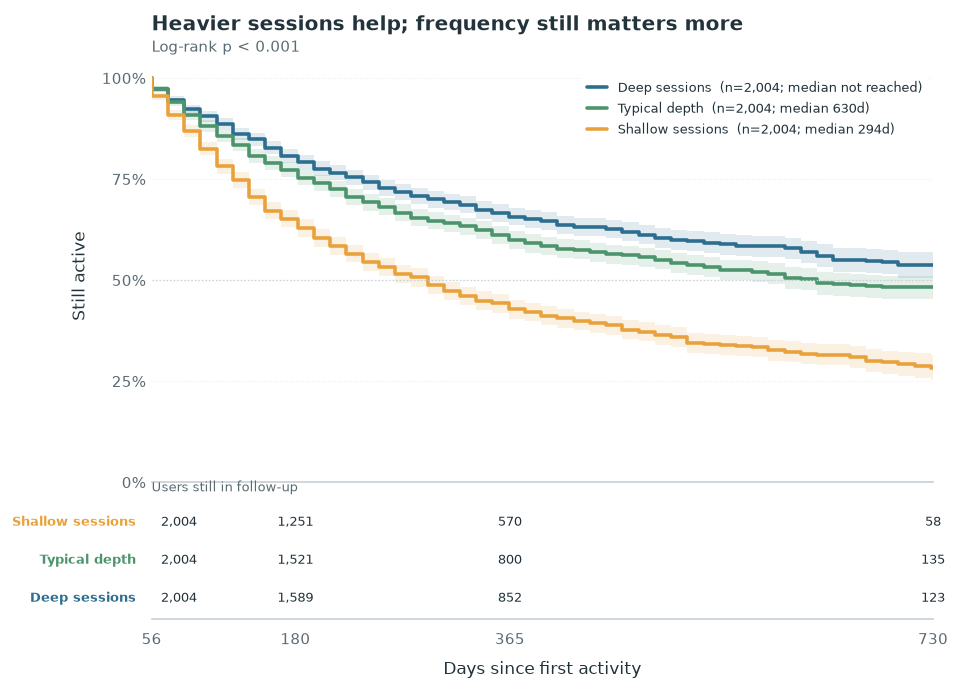

({'Deep sessions': {'sf': <statsmodels.duration.survfunc.SurvfuncRight at 0x11e1962d0>,
   'n': 2004,
   'events': 736,
   'time': array([784, 714, 378, ..., 504, 490, 238], shape=(2004,)),
   'event': array([0, 0, 0, ..., 0, 0, 1], shape=(2004,))},
  'Typical depth': {'sf': <statsmodels.duration.survfunc.SurvfuncRight at 0x11e5a1b80>,
   'n': 2004,
   'events': 862,
   'time': array([630, 350, 630, ..., 756, 266, 448], shape=(2004,)),
   'event': array([1, 0, 0, ..., 0, 0, 0], shape=(2004,))},
  'Shallow sessions': {'sf': <statsmodels.duration.survfunc.SurvfuncRight at 0x11dd71700>,
   'n': 2004,
   'events': 1188,
   'time': array([ 70, 378, 210, ..., 126, 658, 210], shape=(2004,)),
   'event': array([1, 0, 1, ..., 1, 0, 1], shape=(2004,))}},
 1.016370890645544e-57)

In [32]:
depth_order = ["Deep sessions", "Typical depth", "Shallow sessions"]
display(show_table(retention_table(users_56, "session_depth", depth_order)))
plot_km(
    users_56,
    "session_depth",
    title="Heavier sessions help; frequency still matters more",
    filename="09_session_depth.png",
    order=depth_order,
)


## 10. Counting-process Cox — which coefficients move with churn

One model, interval rows, same clock as the R script. Sessions, garage, mix, and the rest can change every 14 days. Read the forest as associations, not “ship this feature”.

User-cluster sandwich SEs did not invert in `statsmodels`; naive SEs **overstate precision**.

| Left out | Why |
|---|---|
| `account_tenure_days` | Equals `interval_end + onboarding_delay_days` exactly. |
| `prop_scan_0_56` | Activity shares sum to ~1; scan is the reference mix. |
| `overall_prop_vehicle_make_volkswagen` | Make shares sum to ~1; VW is the reference garage mix. |
| `CV_gap_0_56_days` | Equals `sd_gap / mean_gap` whenever a gap exists; keep mean + SD (absolute pace and absolute jitter) plus `active_flag` (so filled-zero “no gap” rows are not read as perfectly regular). |
| `recency` | Omitted as a control for current staleness, not because the event row is the 160-day quiet stretch. |


/Users/tomas.p/Desktop/Survival_Analysis_Thesis/.venv/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/var/folders/xr/qsbr7bpn4t1bt2b_d2s0bzp80000gn/T/ipykernel_2607/1031314595.py:27: RuntimeWarning: overflow encountered in exp
  cp_ci = np.exp(cp_fit.conf_int())


Signal,Scale,Hazard ratio,95% CI low,95% CI high,p
overall_prop_vehicle_make_rolls-royce,per +1 SD,0.33,0.00,inf,0.999
Sessions (28d),per +1 SD,0.54,0.48,0.61,< 0.001
Vehicle age SD,per +1 SD,0.84,0.81,0.88,< 0.001
Days since last new vehicle,per +1 SD,0.90,0.84,0.96,0.001
Mean mileage ordinal,per +1 SD,0.91,0.89,0.94,< 0.001
Active flag (56d),per +1 SD,0.95,0.89,1.01,0.116
Škoda (prop),per +1 SD,0.95,0.91,0.99,0.028
Actions/session (28d),per +1 SD,0.96,0.89,1.04,0.312
Audi (prop),per +1 SD,0.96,0.92,1.02,0.170
History screen (prop),per +1 SD,0.97,0.93,1.00,0.065


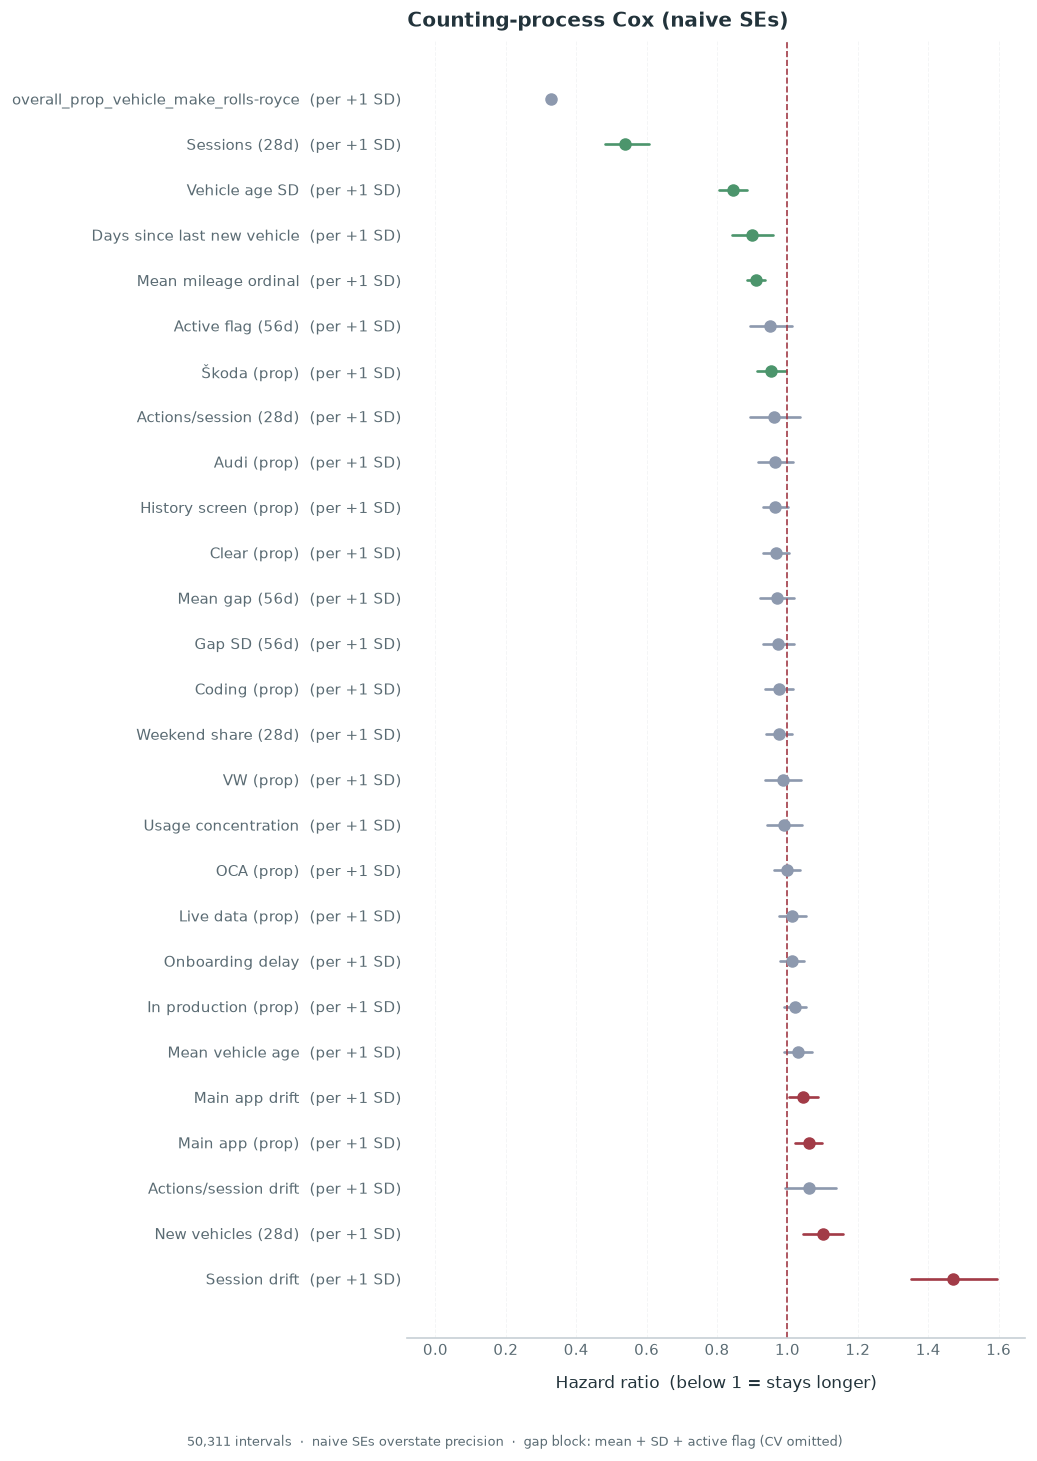

In [33]:
cp_drop = {
    "user_id",
    "interval_start",
    "interval_end",
    "churn_triggered_adjusted",
    "event",
    *vg.COX_BAN_LIST,
}
cp_cols = [c for c in intervals.columns if c not in cp_drop]
X_cp = intervals[cp_cols].astype(float).copy()
X_cp["vehicle_mean_mileage_ordinal"] = np.log1p(X_cp["vehicle_mean_mileage_ordinal"])
X_cp["onboarding_delay_days"] = np.log1p(X_cp["onboarding_delay_days"])
X_cp = (X_cp - X_cp.mean()) / X_cp.std(ddof=0)

cp_fit = PHReg(
    endog=intervals["interval_end"].to_numpy(dtype=float),
    exog=X_cp.to_numpy(dtype=float),
    status=intervals["event"].to_numpy(dtype=int),
    entry=intervals["interval_start"].to_numpy(dtype=float),
    ties="efron",
).fit(disp=0)
assert np.isfinite(cp_fit.params).all() and np.isfinite(cp_fit.bse).all()

cp_ci = np.exp(cp_fit.conf_int())
cp_table = pd.DataFrame(
    {
        "Signal": [vg.pretty_new_features.get(c, c) for c in X_cp.columns],
        "feature": list(X_cp.columns),
        "Scale": "per +1 SD",
        "Hazard ratio": np.exp(cp_fit.params),
        "95% CI low": cp_ci[:, 0],
        "95% CI high": cp_ci[:, 1],
        "p": cp_fit.pvalues,
    }
).sort_values("Hazard ratio")
display(
    cp_table.style.format(
        {
            "Hazard ratio": "{:.2f}",
            "95% CI low": "{:.2f}",
            "95% CI high": "{:.2f}",
            "p": lambda v: format_p(v).replace("p = ", "").replace("p ", ""),
        }
    ).hide(axis="index").hide(["feature"], axis="columns")
)


def plot_forest(table: pd.DataFrame, title: str, filename: str, caption: str) -> None:
    plot_df = table.sort_values("Hazard ratio").iloc[::-1].reset_index(drop=True)
    fig, ax = plt.subplots(figsize=(8.8, 0.38 * len(plot_df) + 1.6))
    y = np.arange(len(plot_df))
    for yi, rec in plot_df.iterrows():
        lo, hi, hr_i = rec["95% CI low"], rec["95% CI high"], rec["Hazard ratio"]
        crosses = lo <= 1 <= hi
        color = (
            style.PALETTE["Neutral"]
            if crosses
            else (style.PALETTE["Personal"] if hr_i < 1 else style.COLORS["highlight"])
        )
        ax.plot([lo, hi], [yi, yi], color=color, lw=1.6, solid_capstyle="round")
        ax.plot(hr_i, yi, "o", color=color, ms=6.5, zorder=3)
    ax.axvline(1.0, color=style.COLORS["highlight"], lw=1.0, ls="--")
    ax.set_yticks(y)
    ax.set_yticklabels(
        [f"{n}  ({s})" for n, s in zip(plot_df["Signal"], plot_df["Scale"])]
    )
    ax.set_xlabel("Hazard ratio  (below 1 = stays longer)", labelpad=10)
    ax.set_title(title, loc="left", pad=8, fontweight="bold")
    fig.tight_layout()
    fig.text(
        0.5,
        -0.02,
        caption,
        ha="center",
        color=style.COLORS["secondary_text"],
        fontsize=8,
    )
    ax.grid(axis="y", visible=False)
    ax.grid(axis="x", linestyle="--", linewidth=0.6, alpha=0.45)
    ax.set_axisbelow(True)
    ax.tick_params(length=0)
    sns.despine(ax=ax, left=True)
    fig.savefig(FIGURE_DIR / filename, bbox_inches="tight", pad_inches=0.35, facecolor=style.COLORS["background"])
    plt.show()


plot_forest(
    cp_table,
    "Counting-process Cox (naive SEs)",
    "10_cox_counting_process.png",
    "50,311 intervals  ·  naive SEs overstate precision  ·  gap block: mean + SD + active flag (CV omitted)",
)


## Most influential coefficients

Ranked by how far the hazard ratio sits from 1 (`|log HR|`), among terms whose naive 95% CI does not include 1; scale is **per +1 SD**.

The clearest adjusted association is recent visit frequency: more active days correspond to lower churn hazard (HR 0.65), while the conditional session-drift coefficient points upward (HR 1.32) and should not be read as a causal effect. Having enough 56-day activity to calculate a gap remains informative (active flag HR 0.84). Greater actions per active day (0.85), a wider spread of vehicle ages (0.84), higher typical mileage (0.89), and a higher coding share (0.92) point toward lower hazard; newly seen vehicles point toward higher hazard (1.14), which is not the same quantity as total garage size.

Mean gap (HR 1.08, p=0.100) and gap SD (HR 0.96, p=0.285) are retained for interpretation but are individually unclear after adjustment. These are exploratory estimates: `statsmodels` reports naive standard errors even though intervals repeat within users, so the confidence intervals and p-values are too optimistic.



In [34]:
notes = {
    "n_sessions_0_28_days": "More distinct active days in the recent 28 days",
    "sessions_intensity_drift_0_28_vs_28_56_days": "Recent 28d visits minus the 28d before that",
    "vehicle_age_sd_overall": "Wider spread of vehicle ages in the garage",
    "actions_per_session_0_28_days": "More actions per active day in the recent 28 days",
    "vehicle_mean_mileage_ordinal": "Higher typical mileage (log1p, then +1 SD)",
    "n_new_vehicles_0_28_days": "More vehicles first seen in the recent 28 days — not the early-garage KM",
    "prop_coding_0_56": "Higher share of coding in the recent mix",
    "active_flag_0_56_days": "At least two active days in 56d, so a gap is observable",
    "sd_gap_0_56_days": "Larger spread of gaps between active days (days)",
    "actions_per_session_intensity_drift_0_28_vs_28_56_days": "Actions/session recent minus prior window",
    "weekend_share_0_28_days": "Higher weekend share of recent actions",
}

ranked = cp_table.copy()
ranked["|log HR|"] = np.abs(np.log(ranked["Hazard ratio"]))
ranked["Direction"] = np.where(ranked["Hazard ratio"] < 1, "Lower hazard (stays longer)", "Higher hazard (leaves sooner)")
ranked["CI excludes 1"] = (ranked["95% CI high"] < 1) | (ranked["95% CI low"] > 1)
summary = (
    ranked.loc[ranked["CI excludes 1"]]
    .sort_values("|log HR|", ascending=False)
    .head(10)
    .copy()
)
summary["What it is"] = summary["feature"].map(notes).fillna("See feature label")
summary["95% CI"] = summary.apply(lambda r: f"{r['95% CI low']:.2f}–{r['95% CI high']:.2f}", axis=1)
display(
    summary[["Signal", "What it is", "Direction", "Hazard ratio", "95% CI", "p"]]
    .style.format(
        {
            "Hazard ratio": "{:.2f}",
            "p": lambda v: format_p(v).replace("p = ", "").replace("p ", ""),
        }
    )
    .hide(axis="index")
    .set_caption(f"Top {len(summary)} of {len(cp_table)} Cox terms by |log HR|, naive CI excluding 1")
)
print(f"{int((~ranked['CI excludes 1']).sum())} of {len(cp_table)} terms have a naive CI that includes 1 (weak / unclear).")


Signal,What it is,Direction,Hazard ratio,95% CI,p
Sessions (28d),More distinct active days in the recent 28 days,Lower hazard (stays longer),0.54,0.48–0.61,< 0.001
Session drift,Recent 28d visits minus the 28d before that,Higher hazard (leaves sooner),1.47,1.35–1.60,< 0.001
Vehicle age SD,Wider spread of vehicle ages in the garage,Lower hazard (stays longer),0.84,0.81–0.88,< 0.001
Days since last new vehicle,See feature label,Lower hazard (stays longer),0.90,0.84–0.96,0.001
New vehicles (28d),More vehicles first seen in the recent 28 days — not the early-garage KM,Higher hazard (leaves sooner),1.10,1.04–1.16,< 0.001
Mean mileage ordinal,"Higher typical mileage (log1p, then +1 SD)",Lower hazard (stays longer),0.91,0.89–0.94,< 0.001
Main app (prop),See feature label,Higher hazard (leaves sooner),1.06,1.02–1.10,0.002
Škoda (prop),See feature label,Lower hazard (stays longer),0.95,0.91–0.99,0.028
Main app drift,See feature label,Higher hazard (leaves sooner),1.04,1.00–1.09,0.030


18 of 27 terms have a naive CI that includes 1 (weak / unclear).


## One-slide board

Four splits on the day-56 sample. Green in the Cox forest is the personal-user palette.


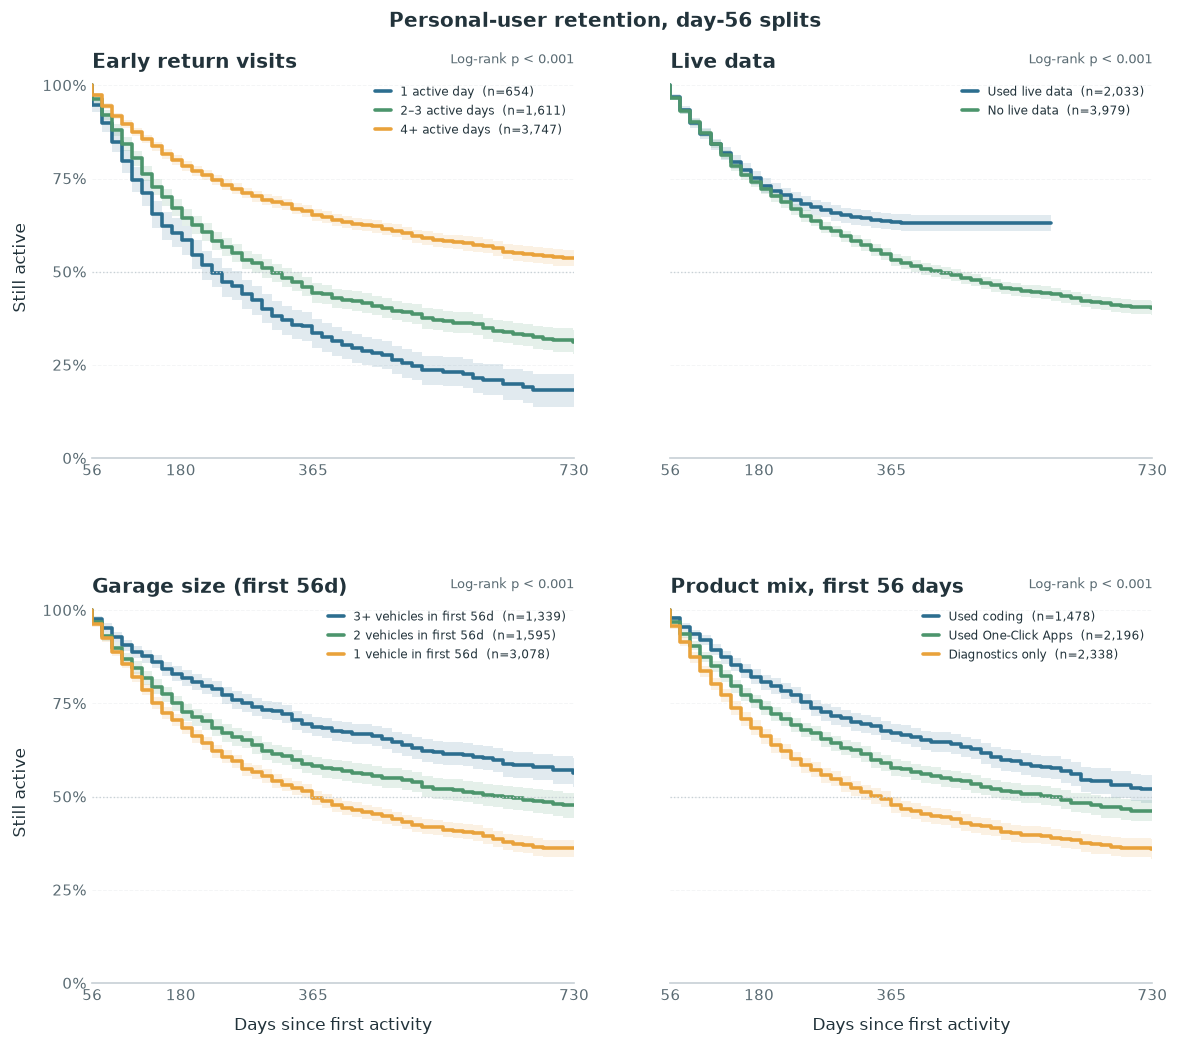

In [35]:
fig, axes = plt.subplots(2, 2, figsize=(11.4, 9.2), sharey=True)
plot_km(
    users_56, "activity_56",
    title="Early return visits",
    filename="_",
    order=activity_order,
    ax=axes[0, 0],
)
plot_km(
    users_56, "live_data",
    title="Live data",
    filename="_",
    order=live_order,
    ax=axes[0, 1],
)
plot_km(
    users_56, "garage",
    title="Garage size (first 56d)",
    filename="_",
    order=garage_order,
    ax=axes[1, 0],
)
plot_km(
    users_56, "feature_mix",
    title="Product mix, first 56 days",
    filename="_",
    order=mix_order,
    ax=axes[1, 1],
)
axes[0, 1].set_ylabel("")
axes[1, 1].set_ylabel("")
for ax in axes[0]:
    ax.set_xlabel("")
fig.suptitle(
    "Personal-user retention, day-56 splits",
    color=style.COLORS["text"],
    fontweight="bold",
    y=0.99,
)
fig.subplots_adjust(hspace=0.38, wspace=0.20, top=0.93)
fig.savefig(FIGURE_DIR / "00_one_slide_board.png", bbox_inches="tight", pad_inches=0.15, facecolor=style.COLORS["background"])
plt.show()


## What this notebook can and cannot say

**Main findings (associations in this personal-user sample):**

- Of 1,945 users, about 48% meet the 160-day inactivity definition; estimated retention is 73% at six months and 57% at one year (median 504 days).
- Among the 1,800 users observed through day 56, the unadjusted KM curves show better one-year retention for users with 4+ active days (68% versus 42% for one-day users), live-data use (79% versus 58%), and 3+ observed vehicles (72% versus 55% for one vehicle).
- In the 26-term counting-process Cox, updated every 14 days, recent visit frequency is the strongest adjusted signal: a +1 SD increase in distinct active days over 28 days corresponds to HR 0.65 (naive 95% CI 0.53–0.79).
- The 56-day active flag remains independently informative (HR 0.84, 0.75–0.95), supporting its role in distinguishing unobservable gap statistics from genuine regularity.
- More actions per active day (HR 0.85), greater vehicle-age spread (0.84), higher typical mileage (0.89), and coding share (0.92) point toward lower hazard; session drift (1.32) and newly observed vehicles (1.14) point upward after adjustment.
- Mean gap (HR 1.08) and gap SD (0.96) remain in the model but are individually unclear; CV is omitted because it equals SD / mean whenever a gap exists.
- Brand shares and most other terms are weak or unclear after adjustment: 18 of 26 naive confidence intervals include 1.

**Limits:**

- These results are associations, not evidence that shipping coding, live data, or a vehicle prompt would cause retention.
- Day-56 KM groups are fixed retrospective labels among users who reached day 56; they are not permanent user types, and their curves correctly start at day 56. Onboarding is the exception: the label is known at first activity, so that KM uses everyone and starts at day 28.
- The Cox new-vehicle term counts vehicles first seen in a moving 28-day window; it is not lifetime garage size and does not contradict the early-garage KM split.
- `recency` is omitted to prevent current staleness from dominating the behavioural model; the modeled event row still precedes the 160-day quiet stretch.
- `account_tenure_days` is omitted because it equals `interval_end + onboarding_delay_days` and therefore has no separately identifiable coefficient on this Cox clock.
- The Cox confidence intervals and p-values are naive because the user-cluster sandwich covariance failed in `statsmodels`; repeated intervals make them too optimistic, so directions and effect sizes are more defensible than significance claims.
- The KM tail after roughly one year is less precise, and nothing here generalises directly to professional/workshop users.


## Talking points

Generated from the fits above so the numbers stay in sync with the charts.

In [36]:
def pct(sf, t):
    return f"{survival_at(sf, t):.0%}"


def group_sf(col, name, frame=None):
    data = users_56 if frame is None else frame
    part = data.loc[data[col] == name]
    return SurvfuncRight(part["time"].to_numpy(), part["event"].to_numpy())


sig = cp_table.set_index("feature")
veh = sig.loc["n_new_vehicles_0_28_days"]
sess = sig.loc["n_sessions_0_28_days"]
miles = sig.loc["vehicle_mean_mileage_ordinal"]
points = [
    (
        f"About {users['event'].mean():.0%} of personal users churn in this sample; "
        f"{pct(overall_sf, 180)} are still active at 6 months and {pct(overall_sf, 365)} at 12 months "
        f"(median time to churn {format_days(median_time(overall_sf))})."
    ),
    (
        f"Among the {len(users_56):,} users followed through day 56, 4+ active days in that window "
        f"retain better at 12 months ({pct(group_sf('activity_56', '4+ active days'), 365)}) "
        f"than one-day users ({pct(group_sf('activity_56', '1 active day'), 365)}) "
        f"(Cox: sessions HR {sess['Hazard ratio']:.2f} per SD)."
    ),
    (
        f"Live-data in the first 56 days: {pct(group_sf('live_data', 'Used live data'), 365)} still active at 12 months vs "
        f"{pct(group_sf('live_data', 'No live data'), 365)} without it on the unadjusted KM; "
        f"Cox live-data share HR {sig.loc['prop_live_data_0_56', 'Hazard ratio']:.2f} per SD."
    ),
    (
        f"Vehicles seen in days 0–56: 3+ vs 1-vehicle 12-month still-active "
        f"{pct(group_sf('garage', '3+ vehicles in first 56d'), 365)} vs "
        f"{pct(group_sf('garage', '1 vehicle in first 56d'), 365)} on the unadjusted KM; "
        f"the interval Cox new-vehicle term is not that early-garage story (HR {veh['Hazard ratio']:.2f} per SD)."
    ),
    (
        f"Coding / OCA shares in the Cox: HR {sig.loc['prop_coding_0_56', 'Hazard ratio']:.2f} and "
        f"{sig.loc['prop_oca_0_56', 'Hazard ratio']:.2f} per SD. Unadjusted KM gaps are mostly visit volume."
    ),
    (
        "VW / Audi / Škoda personal users leave at similar rates — do not spend the meeting on brand mix."
    ),
    (
        "Do not say these graphs show that shipping a feature will cut churn; they show who looks sticky in this personal-user sample."
    ),
]
print("\n".join(f"• {line}" for line in points))
print(f"\nFigures saved to {FIGURE_DIR}")


• About 50% of personal users churn in this sample; 69% are still active at 6 months and 52% at 12 months (median time to churn 420d).
• Among the 6,012 users followed through day 56, 4+ active days in that window retain better at 12 months (65%) than one-day users (34%) (Cox: sessions HR 0.54 per SD).
• Live-data in the first 56 days: 63% still active at 12 months vs 53% without it on the unadjusted KM; Cox live-data share HR 1.01 per SD.
• Vehicles seen in days 0–56: 3+ vs 1-vehicle 12-month still-active 69% vs 50% on the unadjusted KM; the interval Cox new-vehicle term is not that early-garage story (HR 1.10 per SD).
• Coding / OCA shares in the Cox: HR 0.97 and 1.00 per SD. Unadjusted KM gaps are mostly visit volume.
• VW / Audi / Škoda personal users leave at similar rates — do not spend the meeting on brand mix.
• Do not say these graphs show that shipping a feature will cut churn; they show who looks sticky in this personal-user sample.

Figures saved to /Users/tomas.p/Desktop/S